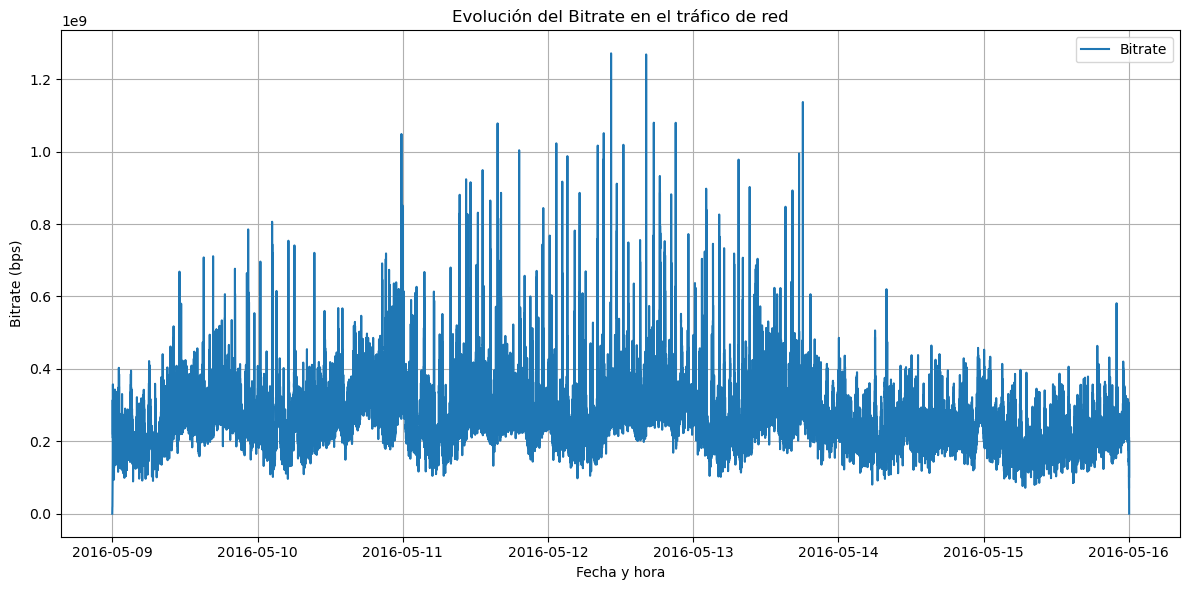

In [4]:
from utilities import *
import matplotlib.pyplot as plt
import pandas as pd

datos = ugr_load_data("may", 3)

#print(datos)

datos['Date'] = pd.to_datetime(datos['Date'])

plt.figure(figsize=(12, 6))

plt.plot(datos['Date'], datos['Bitrate'], label='Bitrate')

plt.xlabel('Fecha y hora')
plt.ylabel('Bitrate (bps)')
plt.title('Evolución del Bitrate en el tráfico de red')
plt.legend()
plt.grid(True)
#plt.savefig("figuras_memoria/mayo_3semana.pdf")
plt.tight_layout()
plt.show()


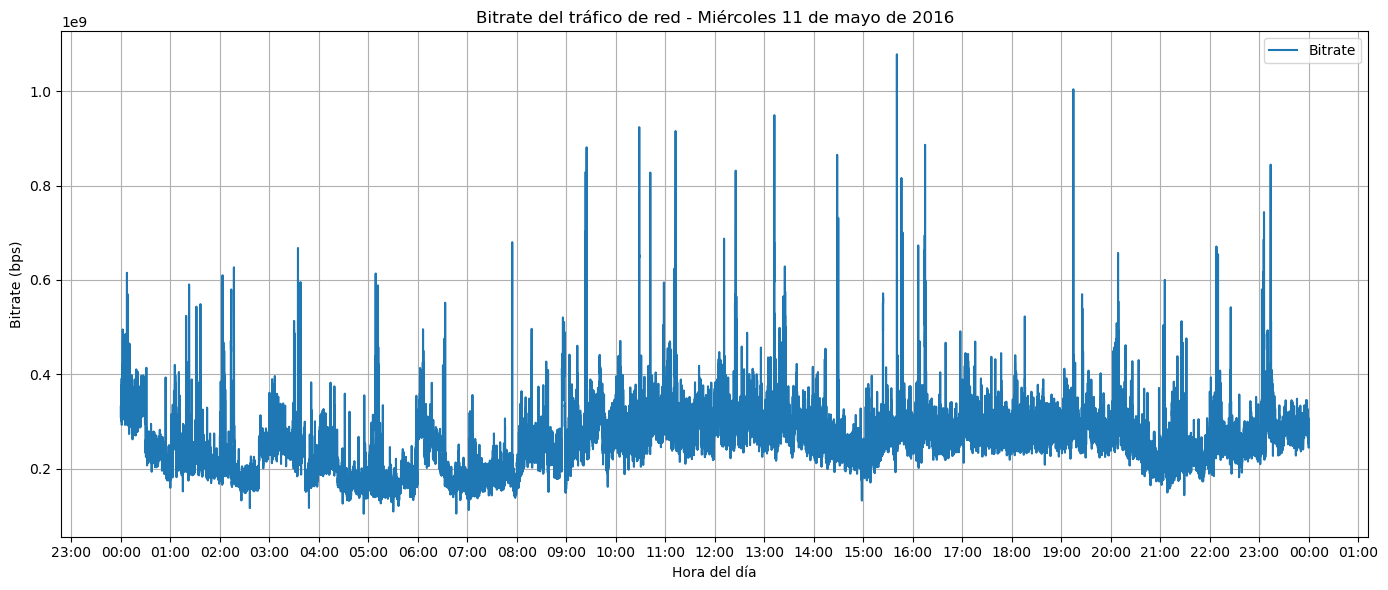

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from utilities import *

datos = ugr_load_data("may", 3)

# Filtrar solo el 11 de mayo de 2016
fecha_objetivo = pd.to_datetime("2016-05-11")
datos_miercoles = datos[
    datos["Date"].dt.date == fecha_objetivo.date()
].reset_index(drop=True)

plt.figure(figsize=(14, 6))
plt.plot(datos_miercoles["Date"], datos_miercoles["Bitrate"], label="Bitrate")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))

plt.xlabel("Hora del día")
plt.ylabel("Bitrate (bps)")
plt.title("Bitrate del tráfico de red - Miércoles 11 de mayo de 2016")
plt.grid(True)
plt.legend()
#plt.savefig("figuras_memoria/ventana_miercoles.pdf")
plt.tight_layout()
plt.show()



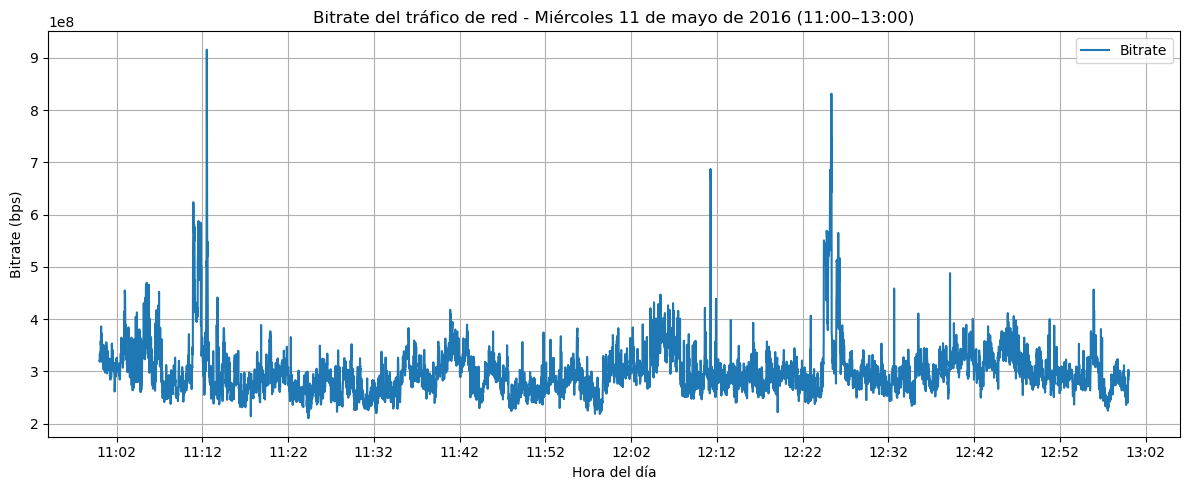

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from utilities import *

datos = ugr_load_data("may", 3)

# Filtrar solo el 11 de mayo de 2016
fecha_objetivo = pd.to_datetime("2016-05-11")
datos_miercoles = datos[datos["Date"].dt.date == fecha_objetivo.date()].reset_index(drop=True)

# Obtener el segmento de 11:00 a 13:00
segmento = ugr_get_few_minutes(datos_miercoles, offset=11*60, minutes=120)

plt.figure(figsize=(12, 5))
plt.plot(segmento["Date"], segmento["Bitrate"], label="Bitrate")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=10))

plt.xlabel("Hora del día")
plt.ylabel("Bitrate (bps)")
plt.title("Bitrate del tráfico de red - Miércoles 11 de mayo de 2016 (11:00–13:00)")
plt.grid(True)
plt.legend()
#plt.savefig("figuras_memoria/ventana_miercoles_11_13.pdf")
plt.tight_layout()
plt.show()


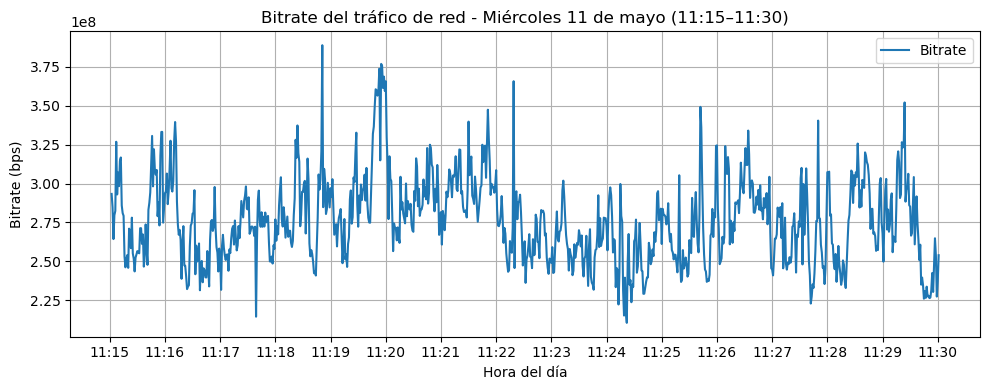

In [7]:
# Obtener solo los primeros 15 minutos (desde las 11:00 a las 11:15)
primeros_15 = ugr_get_few_minutes(segmento, offset=15, minutes=15) #offset es el momento en el que empieza, minutes es la duracion

plt.figure(figsize=(10, 4))
plt.plot(primeros_15["Date"], primeros_15["Bitrate"], label="Bitrate")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=1))

plt.xlabel("Hora del día")
plt.ylabel("Bitrate (bps)")
plt.title("Bitrate del tráfico de red - Miércoles 11 de mayo (11:15–11:30)")
plt.grid(True)
plt.legend()
#plt.savefig("figuras_memoria/ventana_11_1115.pdf")
plt.tight_layout()
plt.show()


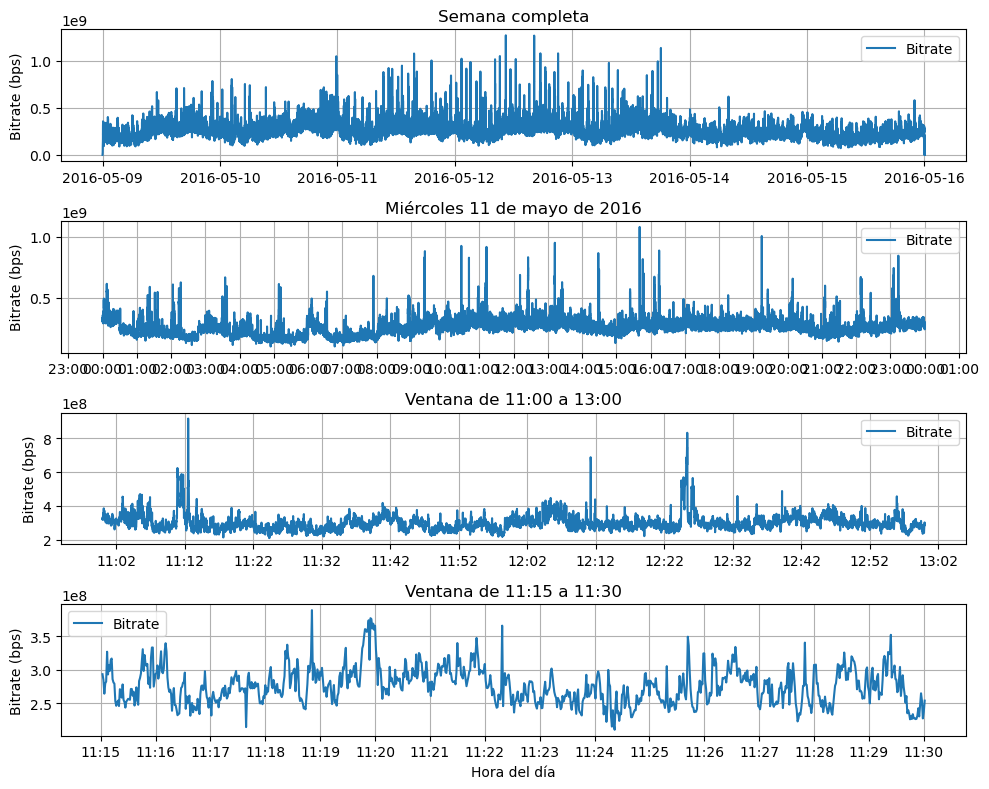

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from utilities import *

datos = ugr_load_data("may", 3)
datos['Date'] = pd.to_datetime(datos['Date'])

full_data = datos

# Miércoles 11 de mayo de 2016
fecha_objetivo = pd.to_datetime("2016-05-11")
datos_miercoles = datos[datos["Date"].dt.date == fecha_objetivo.date()].reset_index(drop=True)

# Segmento de 11:00 a 13:00
segmento = ugr_get_few_minutes(datos_miercoles, offset=11*60, minutes=120)

# Primeros 15 minutos desde las 11:15
primeros_15 = ugr_get_few_minutes(segmento, offset=15, minutes=15)

fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=False)

# --- Gráfico 1: Semana completa ---
axs[0].plot(full_data['Date'], full_data['Bitrate'], label='Bitrate')
axs[0].set_title('Semana completa')
axs[0].set_ylabel('Bitrate (bps)')
axs[0].grid(True)
axs[0].legend()

# --- Gráfico 2: Miércoles completo ---
axs[1].plot(datos_miercoles['Date'], datos_miercoles['Bitrate'], label='Bitrate')
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[1].xaxis.set_major_locator(mdates.HourLocator(interval=1))
axs[1].set_title('Miércoles 11 de mayo de 2016')
axs[1].set_ylabel('Bitrate (bps)')
axs[1].grid(True)
axs[1].legend()

# --- Gráfico 3: 11:00 a 13:00 ---
axs[2].plot(segmento['Date'], segmento['Bitrate'], label='Bitrate')
axs[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[2].xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
axs[2].set_title('Ventana de 11:00 a 13:00')
axs[2].set_ylabel('Bitrate (bps)')
axs[2].grid(True)
axs[2].legend()

# --- Gráfico 4: 11:15 a 11:30 ---
axs[3].plot(primeros_15['Date'], primeros_15['Bitrate'], label='Bitrate')
axs[3].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[3].xaxis.set_major_locator(mdates.MinuteLocator(interval=1))
axs[3].set_title('Ventana de 11:15 a 11:30')
axs[3].set_xlabel('Hora del día')
axs[3].set_ylabel('Bitrate (bps)')
axs[3].grid(True)
axs[3].legend()

# Ajustar distribución
plt.tight_layout()
#plt.savefig("figuras_memoria/enventanado_todos_pequeña.pdf")
plt.show()


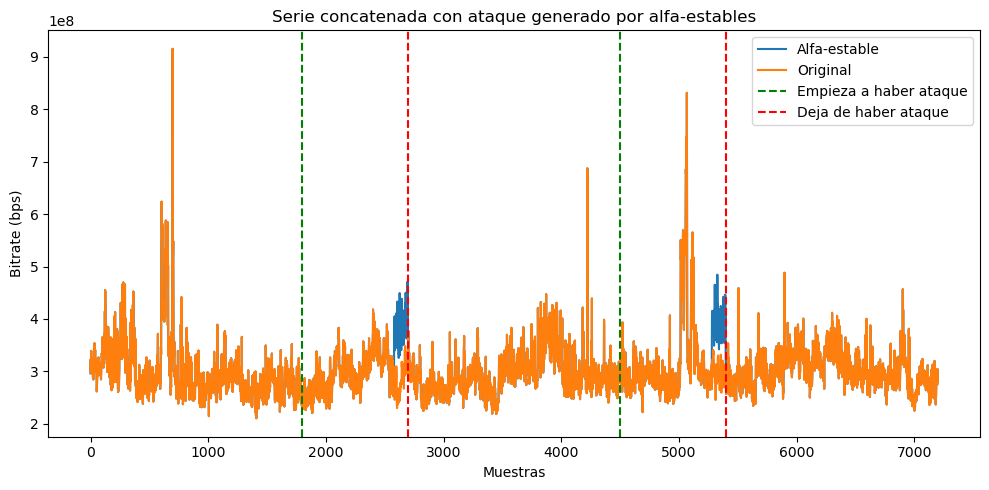

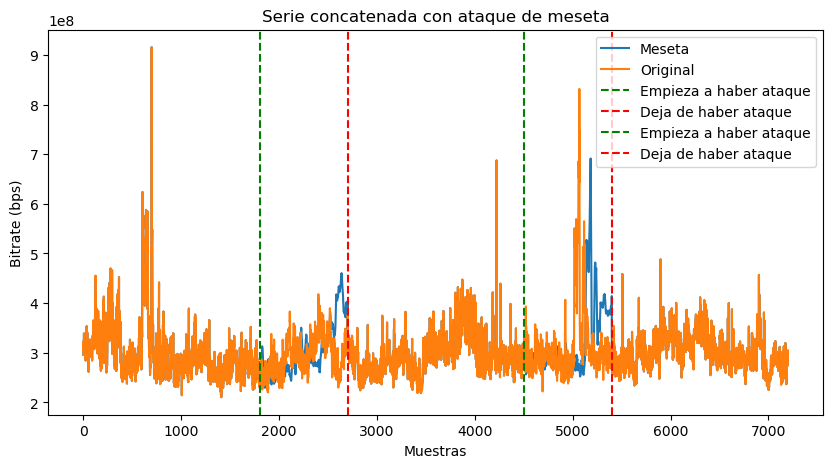

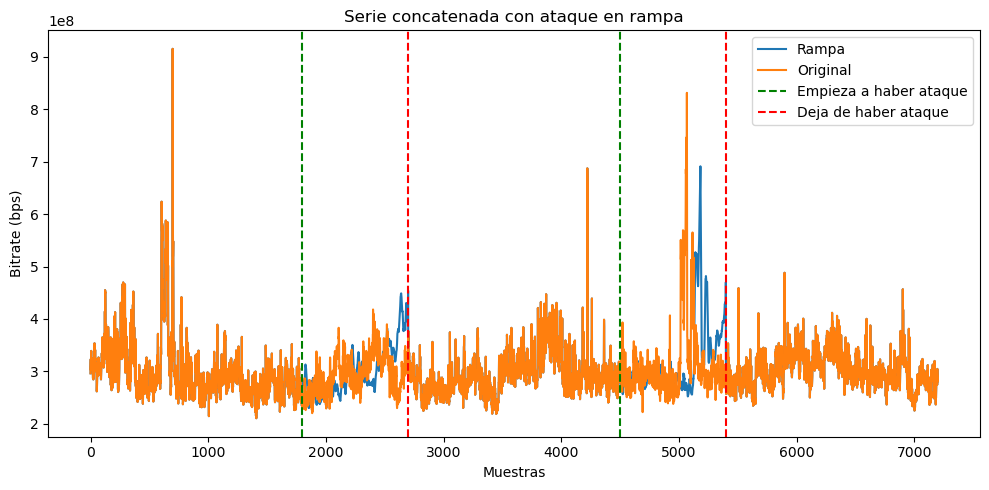

In [9]:
df_concatenado_miercoles_sin_ataque = pd.read_csv("series_concatenadas_sin_ataque/archivo_concatenado_miercoles_sin_ataque.csv", header=None)[0]
df_concatenado_miercoles_alfa = pd.read_csv("series_concatenadas/archivo_concatenado_miercoles.csv", header=None)[0]
df_concatenado_miercoles_meseta = pd.read_csv("series_concatenadas_meseta/archivo_concatenado_miercoles.csv", header=None)[0]
df_concatenado_miercoles_rampa = pd.read_csv("series_concatenadas_rampa/archivo_concatenado_miercoles.csv", header=None)[0]



plt.figure(figsize=(10,5))
plt.plot(df_concatenado_miercoles_alfa, label="Alfa-estable")
plt.plot(df_concatenado_miercoles_sin_ataque, label="Original")
plt.axvline(x=1801, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
plt.axvline(x=4501, color='green', linestyle='--')
plt.axvline(x=5400, color='red', linestyle='--')
plt.legend()
plt.xlabel("Muestras")
plt.ylabel("Bitrate (bps)")
plt.title("Serie concatenada con ataque generado por alfa-estables")
#plt.savefig("figuras_memoria/serie_concatenada_alfa_miercoles.pdf")
#plt.savefig("figuras_memoria/serie_concatenada_alfa_miercoles.svg")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10,5))
plt.plot(df_concatenado_miercoles_meseta, label="Meseta")
plt.plot(df_concatenado_miercoles_sin_ataque, label="Original")
plt.axvline(x=1801, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
plt.axvline(x=4501, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=5400, color='red', linestyle='--', label='Deja de haber ataque')
plt.legend()
plt.xlabel("Muestras")
plt.ylabel("Bitrate (bps)")
plt.title("Serie concatenada con ataque de meseta")
#plt.savefig("figuras_memoria/serie_concatenada_meseta_miercoles.pdf")
#plt.savefig("figuras_memoria/serie_concatenada_meseta_miercoles.svg")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df_concatenado_miercoles_rampa, label="Rampa")
plt.plot(df_concatenado_miercoles_sin_ataque, label="Original")
plt.axvline(x=1801, color='green', linestyle='--', label='Empieza a haber ataque')
plt.axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
plt.axvline(x=4501, color='green', linestyle='--')
plt.axvline(x=5400, color='red', linestyle='--')
plt.legend()
plt.xlabel("Muestras")
plt.ylabel("Bitrate (bps)")
plt.title("Serie concatenada con ataque en rampa")
#plt.savefig("figuras_memoria/serie_concatenada_rampa_miercoles.pdf")
#plt.savefig("figuras_memoria/serie_concatenada_rampa_miercoles.svg")
plt.tight_layout()
plt.show()



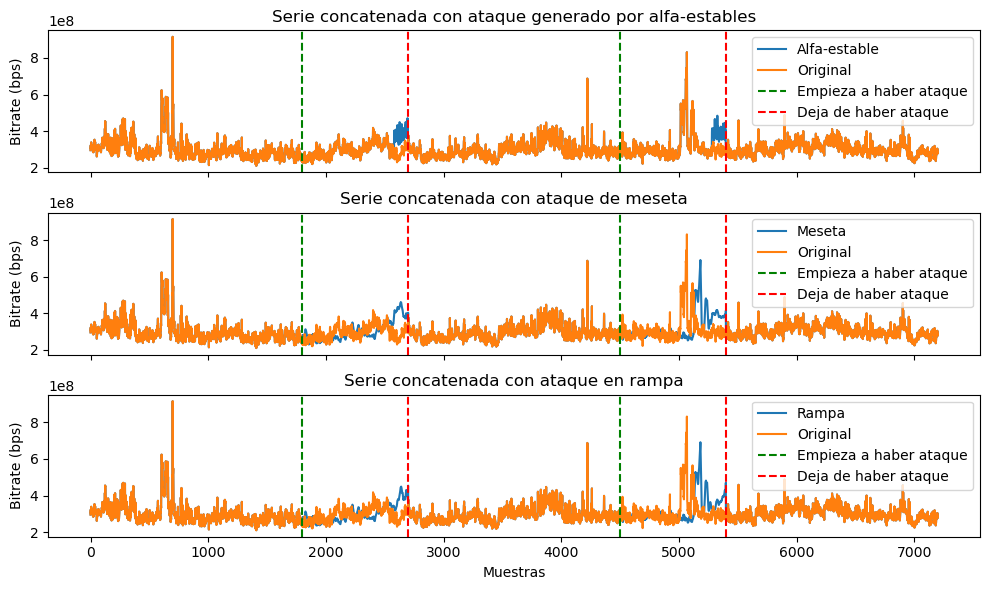

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df_concatenado_miercoles_sin_ataque = pd.read_csv("series_concatenadas_sin_ataque/archivo_concatenado_miercoles_sin_ataque.csv", header=None)[0]
df_concatenado_miercoles_alfa = pd.read_csv("series_concatenadas/archivo_concatenado_miercoles.csv", header=None)[0]
df_concatenado_miercoles_meseta = pd.read_csv("series_concatenadas_meseta/archivo_concatenado_miercoles.csv", header=None)[0]
df_concatenado_miercoles_rampa = pd.read_csv("series_concatenadas_rampa/archivo_concatenado_miercoles.csv", header=None)[0]

fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

axs[0].plot(df_concatenado_miercoles_alfa, label="Alfa-estable")
axs[0].plot(df_concatenado_miercoles_sin_ataque, label="Original")
axs[0].axvline(x=1801, color='green', linestyle='--', label='Empieza a haber ataque')
axs[0].axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
axs[0].axvline(x=4501, color='green', linestyle='--')
axs[0].axvline(x=5400, color='red', linestyle='--')
axs[0].set_ylabel("Bitrate (bps)")
axs[0].set_title("Serie concatenada con ataque generado por alfa-estables")
axs[0].legend()

axs[1].plot(df_concatenado_miercoles_meseta, label="Meseta")
axs[1].plot(df_concatenado_miercoles_sin_ataque, label="Original")
axs[1].axvline(x=1801, color='green', linestyle='--', label='Empieza a haber ataque')
axs[1].axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
axs[1].axvline(x=4501, color='green', linestyle='--')
axs[1].axvline(x=5400, color='red', linestyle='--')
axs[1].set_ylabel("Bitrate (bps)")
axs[1].set_title("Serie concatenada con ataque de meseta")
axs[1].legend()

axs[2].plot(df_concatenado_miercoles_rampa, label="Rampa")
axs[2].plot(df_concatenado_miercoles_sin_ataque, label="Original")
axs[2].axvline(x=1801, color='green', linestyle='--', label='Empieza a haber ataque')
axs[2].axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
axs[2].axvline(x=4501, color='green', linestyle='--')
axs[2].axvline(x=5400, color='red', linestyle='--')
axs[2].set_xlabel("Muestras")
axs[2].set_ylabel("Bitrate (bps)")
axs[2].set_title("Serie concatenada con ataque en rampa")
axs[2].legend()

plt.tight_layout()
#plt.savefig("figuras_memoria/series_concatenadas_todas.pdf")
plt.show()



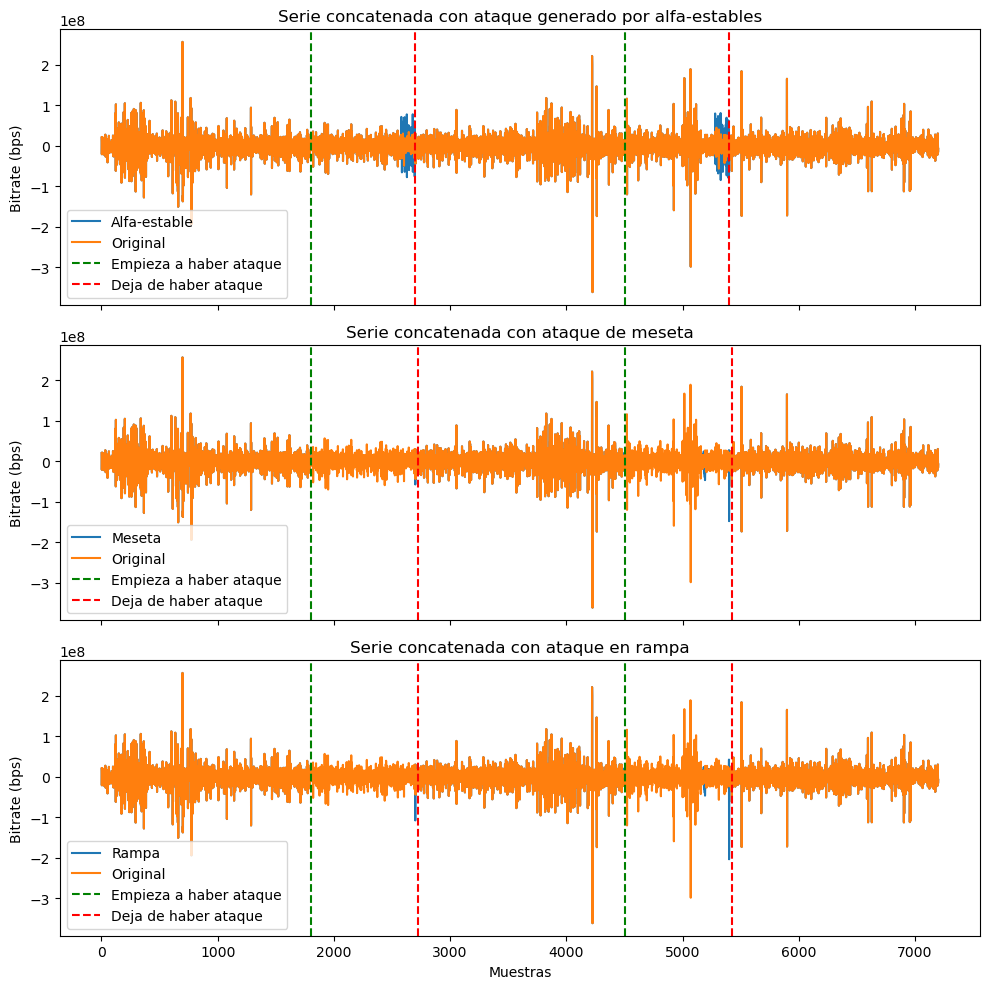

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df_concatenado_miercoles_sin_ataque = pd.read_csv("series_concatenadas_sin_ataque/archivo_concatenado_miercoles_sin_ataque_diff.csv", header=None)[0]
df_concatenado_miercoles_alfa = pd.read_csv("series_concatenadas/archivo_concatenado_miercoles_diff.csv", header=None)[0]
df_concatenado_miercoles_meseta = pd.read_csv("series_concatenadas_meseta/archivo_concatenado_miercoles_diff.csv", header=None)[0]
df_concatenado_miercoles_rampa = pd.read_csv("series_concatenadas_rampa/archivo_concatenado_miercoles_diff.csv", header=None)[0]

fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axs[0].plot(df_concatenado_miercoles_alfa, label="Alfa-estable")
axs[0].plot(df_concatenado_miercoles_sin_ataque, label="Original")
axs[0].axvline(x=1801, color='green', linestyle='--', label='Empieza a haber ataque')
axs[0].axvline(x=2700, color='red', linestyle='--', label='Deja de haber ataque')
axs[0].axvline(x=4501, color='green', linestyle='--')
axs[0].axvline(x=5400, color='red', linestyle='--')
axs[0].set_ylabel("Bitrate (bps)")
axs[0].set_title("Serie concatenada con ataque generado por alfa-estables")
axs[0].legend()

axs[1].plot(df_concatenado_miercoles_meseta, label="Meseta")
axs[1].plot(df_concatenado_miercoles_sin_ataque, label="Original")
axs[1].axvline(x=1801, color='green', linestyle='--', label='Empieza a haber ataque')
axs[1].axvline(x=2725, color='red', linestyle='--', label='Deja de haber ataque')
axs[1].axvline(x=4501, color='green', linestyle='--')
axs[1].axvline(x=5425, color='red', linestyle='--')
axs[1].set_ylabel("Bitrate (bps)")
axs[1].set_title("Serie concatenada con ataque de meseta")
axs[1].legend()

axs[2].plot(df_concatenado_miercoles_rampa, label="Rampa")
axs[2].plot(df_concatenado_miercoles_sin_ataque, label="Original")
axs[2].axvline(x=1801, color='green', linestyle='--', label='Empieza a haber ataque')
axs[2].axvline(x=2725, color='red', linestyle='--', label='Deja de haber ataque')
axs[2].axvline(x=4501, color='green', linestyle='--')
axs[2].axvline(x=5425, color='red', linestyle='--')
axs[2].set_xlabel("Muestras")
axs[2].set_ylabel("Bitrate (bps)")
axs[2].set_title("Serie concatenada con ataque en rampa")
axs[2].legend()

plt.tight_layout()
#plt.savefig("figuras_memoria/difs_finitas_todas.pdf")
plt.show()